In [1]:
from utils import *
import seaborn as sns

In [2]:
git_zinc = '../gnn-lspe/out/GraphiT_ZINC_NoPE/logs/GraphiT_ZINC_GPU0_2025_02_03_15h14m59s/RUN_0/malog.pkl'
san_zinc = '../SAN/out/ZINC/sparse/1e-5/none/logs/GraphTransformer_ZINC_GPU0_2025_02_03_15h40m24s/RUN_0/malog.pkl'
san_zinc_train = "../SAN/out/ZINC/sparse/1e-5/none/logs/GraphTransformer_ZINC_GPU0_2025_02_04_15h03m16s/RUN_0/malog.pkl"
gt_tox = "../graphtransformer/out/TOX21_sparse_NoPE_BN/logs/GraphTransformer_TOX21_GPU0_2025_Feb_04_15h21m20s/RUN_0/malog.pkl"
gt_zinc_global = "../graphtransformer/out/ZINC-GLOBAL_sparse_NoPE_BN/logs/GraphTransformer_ZINC-GLOBAL_GPU0_2025_Feb_04_16h26m52s/RUN_0/malog.pkl"
gt_zinc_global_3 = "../graphtransformer/out/ZINC-GLOBAL_sparse_NoPE_BN/logs/GraphTransformer_ZINC-GLOBAL_GPU0_2025_Feb_04_16h47m10s/RUN_0/malog.pkl"
gt_zinc_global_4_5 = "../graphtransformer/out/ZINC-GLOBAL_sparse_NoPE_BN/logs/GraphTransformer_ZINC-GLOBAL_GPU0_2025_Feb_05_09h10m15s/RUN_0/malog.pkl"
gt_zinc_random_edges = "../graphtransformer/out/ZINC-GLOBAL_sparse_NoPE_BN/logs/GraphTransformer_ZINC-GLOBAL_GPU0_2025_Feb_05_12h15m02s/RUN_0/malog.pkl"

log = gt_tox
layer = 0

In [56]:
def heatma(log, layer:int=0, threshold:float=None, feat='e', filename='heat.pdf'):
    with open(log, 'rb') as fp:
        a = pickle.load(fp)
    b = get_values(a, feat=feat, use_layers=[layer], use_abs=False, flatten=False, cat_batches=False)
    data = b[layer]
    types = a['model.edge_types']
    c = {}
    for dd,tt in zip(data, types):
        for d,t in zip(dd, tt.tolist()):
            if t not in c:
                c[t] = []
            c[t].append(d.numpy())
    # normalize + median + filter
    for k,v in c.items():
        for i in range(len(v)):
            v[i] = np.abs(v[i]) # absolute value
            v[i] = v[i]/np.median(v[i]) # edge median or graph median?
            if threshold is not None:
                v[i] = (v[i] > threshold).astype(np.float32) # filter MA
    print(log, layer, threshold)
    
    # fig,axes = plt.subplots(1,len(c), figsize=(4.97*len(c),4.8))
    # fig,axes = plt.subplots(1,len(c), figsize=(3.75*len(c),3.6))
    x_len = 7.5 if len(c) == 3 else 12.25 if len(c) == 5 else 2.5*len(c)
    print(x_len)
    fig,axes = plt.subplots(1,len(c), figsize=(x_len,2.7))
    q = {}
    d = {}
    for i,(k,v) in enumerate(sorted(c.items())):
        print("Quantity of", k, len(v))
        q[k] = len(v)
        d[k] = np.average(np.stack(v),axis=0).reshape(8,-1)*100
    vmax = max(x.max() for x in d.values()) if threshold is None else 100
    # keys = list(sorted(d.keys()))
    for i,(k,v) in enumerate(sorted(d.items())):
        sns.heatmap(v, vmin=0, vmax=vmax, cmap='coolwarm', cbar=False, rasterized=True, cbar_kws={'label': '%'}, ax=axes[i]).set(title=f'edge type {k} - {q[k]/sum(q.values())*100:.2f}%')
        if i == len(d)//2:
            axes[i].set_xlabel('Attention head')
    axes[0].set_ylabel('Feature dimension')
    cbar_ax = fig.add_axes([0.92, 0.215, 0.01, 0.647])  # [left, bottom, width, height]
    sns.heatmap(
        v,
        vmin=0,
        vmax=vmax,
        cmap='coolwarm',
        cbar=True,
        rasterized=True,
        cbar_ax=cbar_ax,
        cbar_kws={'label': '%'},
        ax=axes[-1]
    )

    # fig.supxlabel('Attention head')
    # fig.supylabel('Feature dimension')
    plt.tight_layout(rect=[0, 0, 0.9, 1]) 
    plt.savefig(filename)

../gnn-lspe/out/GraphiT_ZINC_NoPE/logs/GraphiT_ZINC_GPU0_2025_02_03_15h14m59s/RUN_0/malog.pkl 0 4000
Quantity of 1 37050
Quantity of 2 12542
Quantity of 3 128


/tmp/ipykernel_3458720/863185518.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


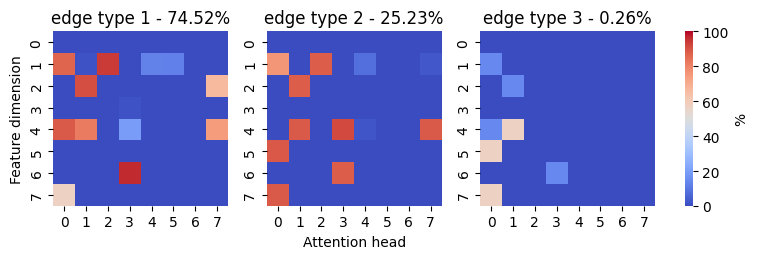

In [52]:
heatma(git_zinc, threshold=4000, filename='heat_git.pdf')

../graphtransformer/out/ZINC-GLOBAL_sparse_NoPE_BN/logs/GraphTransformer_ZINC-GLOBAL_GPU0_2025_Feb_05_09h10m15s/RUN_0/malog.pkl 0 3000
12.25
Quantity of 1 37050
Quantity of 2 12542
Quantity of 3 128
Quantity of 4 23117
Quantity of 5 23117


/tmp/ipykernel_3458720/3208211897.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


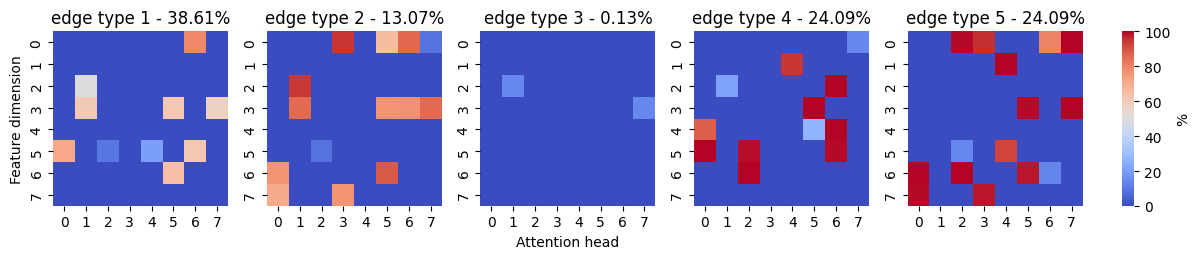

In [57]:
heatma(gt_zinc_global_4_5, threshold=3000, filename='heat_abl.pdf')